In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/AI-OCR dataset"

In [ ]:
import os

image_files = [f for f in os.listdir(DATASET_PATH) if f.endswith(('.jpg','.png','.jpeg'))]

print("Total images:", len(image_files))
print(image_files[:5])

Total images: 370
['0.jpg', '18.jpg', 'X51005230616.jpg', 'X51005230659.jpg', 'X51005268408.jpg']


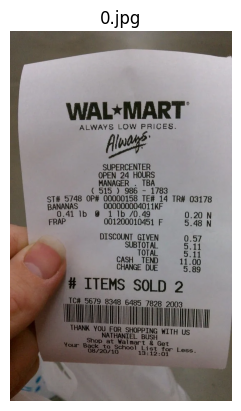

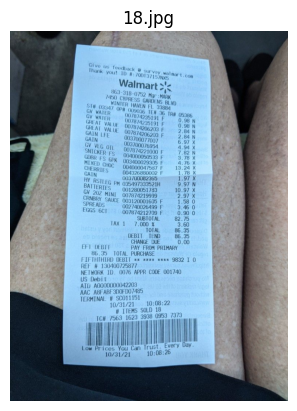

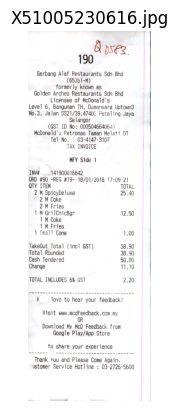

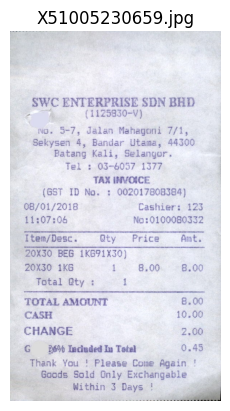

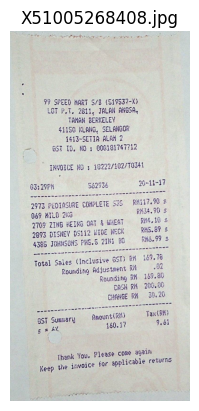

In [ ]:
import cv2
import matplotlib.pyplot as plt

for img_name in image_files[:5]:
    img = cv2.imread(os.path.join(DATASET_PATH, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title(img_name)
    plt.axis('off')
    plt.show()

In [ ]:
!pip install easyocr opencv-python-headless pillow pandas numpy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 26.3 MB/s eta 0:00:00


In [ ]:
import os, re, json, cv2
import numpy as np
import pandas as pd
import easyocr
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

DATASET_PATH = "/content/drive/MyDrive/AI-OCR dataset"
OUTPUT_PATH = "/content/outputs"
os.makedirs(OUTPUT_PATH, exist_ok=True)

reader = easyocr.Reader(['en'], gpu=True)  # gpu=False if no GPU
print("EasyOCR loaded ✅")

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteEasyOCR loaded ✅


In [ ]:
def preprocess_image(img_path):
    """
    Returns a cleaned, deskewed, binarized image ready for OCR.
    """
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Cannot read image: {img_path}")

    # 1. Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Denoise
    denoised = cv2.fastNlMeansDenoising(gray, h=15)

    # 3. Contrast enhancement (CLAHE)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(denoised)

    # 4. Binarize (Otsu thresholding)
    _, binary = cv2.threshold(
        enhanced, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # 5. Deskew
    coords = np.column_stack(np.where(binary > 0))
    if len(coords) > 0:
        angle = cv2.minAreaRect(coords)[-1]
        angle = -(90 + angle) if angle < -45 else -angle
        if abs(angle) < 30:          # only correct small angles
            (h, w) = binary.shape
            M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
            binary = cv2.warpAffine(
                binary, M, (w, h),
                flags=cv2.INTER_CUBIC,
                borderMode=cv2.BORDER_REPLICATE
            )

    return binary

In [ ]:
def run_ocr(img_path):
    """
    Returns list of (text, confidence) tuples.
    """
    processed = preprocess_image(img_path)
    results = reader.readtext(processed, detail=1)
    # results: [ [bbox, text, conf], ... ]
    lines = [(res[1].strip(), float(res[2])) for res in results if res[1].strip()]
    return lines

In [ ]:
DATE_PATTERNS = [
    r'\b(\d{1,2}[\/\-\.]\d{1,2}[\/\-\.]\d{2,4})\b',
    r'\b(\d{4}[\/\-\.]\d{1,2}[\/\-\.]\d{1,2})\b',
    r'\b([A-Za-z]{3,9}\.?\s+\d{1,2},?\s+\d{4})\b',
    r'\b(\d{1,2}\s+[A-Za-z]{3,9}\s+\d{4})\b',
]

# Matches: 1.99 / 12.50 / $5.00 / 1,234.56
PRICE_PATTERN = r'\$?\s*(\d{1,4}[,\d]*\.\d{2})\b'

TOTAL_KEYWORDS = [
    'total', 'jumlah', 'amount', 'balance', 'grand',
    'subtotal', 'sub total', 'net', 'due', 'payment',
    'charge', 'bayaran', 'amaun'          # Malay keywords for Malaysian receipts
]

SKIP_KEYWORDS = [
    'tax', 'gst', 'sst', 'cash', 'change', 'tender',
    'thank', 'save', 'you', 'discount', 'member',
    'phone', 'tel', 'fax', 'http', 'www'
]

STORE_KEYWORDS = [
    # US
    'walmart', 'wal-mart', 'wal mart', 'target', 'costco',
    'kroger', "trader joe", 'whole foods', 'walgreens', 'cvs',
    'aldi', 'safeway', 'publix', "sam's club", 'sams club',
    'dollar', 'seven eleven', '7-eleven', 'starbucks', 'mcdonald',
    # Malaysian (based on your dataset samples)
    'pasaraya', 'borong', 'unihakka', 'mydin', 'giant',
    'tesco', 'aeon', 'lotus', 'econsave', 'sdn bhd', 'berhad',
]

def extract_store(lines):
    # Pass 1: keyword match in first 10 lines, skip addresses
    for text, conf in lines[:10]:
        if is_address(text):
            continue
        lower = text.lower()
        for kw in STORE_KEYWORDS:
            if kw in lower:
                return text.strip(), round(min(conf + 0.15, 1.0), 3)

    # Pass 2: first non-address, non-numeric line with decent confidence
    for text, conf in lines[:8]:
        if is_address(text):
            continue
        if len(text.strip()) < 4:
            continue
        if re.fullmatch(r'[\d\s\W]+', text.strip()):
            continue
        return text.strip(), round(conf * 0.6, 3)

    return None, 0.0


def extract_date(lines):
    for text, conf in lines:
        for pat in DATE_PATTERNS:
            m = re.search(pat, text, re.IGNORECASE)
            if m:
                return m.group(1), round(0.5 * conf + 0.5, 3)
    return None, 0.0


def extract_total(lines):
    """
    Priority: TOTAL > GRAND TOTAL > AMOUNT > SUBTOTAL > largest price
    """
    PRIORITY = ['grand total', 'total amount', 'jumlah besar',
                'amaun', 'total', 'amount due', 'balance due',
                'jumlah', 'subtotal', 'sub total']

    found = []
    for i, (text, conf) in enumerate(lines):
        lower = text.lower()

        for rank, kw in enumerate(PRIORITY):
            if kw in lower:
                # same line
                m = re.search(PRICE_PATTERN, text)
                if m:
                    val = float(m.group(1).replace(',', ''))
                    if val > 0:
                        found.append((rank, val, conf, 'same_line'))
                # next line
                elif i + 1 < len(lines):
                    m2 = re.search(PRICE_PATTERN, lines[i+1][0])
                    if m2:
                        val = float(m2.group(1).replace(',', ''))
                        if val > 0:
                            found.append((rank, val, conf * 0.9, 'next_line'))
                break  # only match highest priority keyword per line

    if found:
        # sort by priority rank (lower = better), then by value (larger = better)
        found.sort(key=lambda x: (x[0], -x[2]))
        best = found[0]
        score = round(0.4 * best[2] + 0.35 * (1 - best[0]/len(PRIORITY)) + 0.25, 3)
        return str(round(best[1], 2)), min(score, 1.0)

    # Fallback: largest price in document
    all_prices = []
    for text, conf in lines:
        for m in re.finditer(PRICE_PATTERN, text):
            try:
                val = float(m.group(1).replace(',', ''))
                if 0.5 < val < 9999:     # sanity bounds
                    all_prices.append((val, conf))
            except:
                pass
    if all_prices:
        best_val, best_conf = max(all_prices, key=lambda x: x[0])
        return str(round(best_val, 2)), round(best_conf * 0.35, 3)

    return None, 0.0


def extract_items(lines):
    items = []
    HARD_SKIP = SKIP_KEYWORDS + TOTAL_KEYWORDS + [
        'receipt', 'invoice', 'tax', 'reg', 'cashier',
        'thank', 'welcome', 'please', 'survey', 'phone',
        'tel', 'fax', 'address', 'manager', 'open', 'hours',
        'store', 'stw', 'tc#', 'trx', 'network', 'terminal'
    ]

    i = 0
    while i < len(lines):
        text, conf = lines[i]
        lower = text.lower()

        # hard skip
        if any(kw in lower for kw in HARD_SKIP):
            i += 1
            continue
        if len(text.strip()) < 3:
            i += 1
            continue
        # skip pure barcodes / IDs
        if re.fullmatch(r'[\d\s\*\#\-\.]+', text.strip()):
            i += 1
            continue

        # Case 1: price on same line as name
        m = re.search(PRICE_PATTERN, text)
        if m:
            price = m.group(1).replace(',', '')
            name  = re.sub(PRICE_PATTERN, '', text).strip(' .,-\t*#@')
            name  = re.sub(r'\s{2,}', ' ', name)
            try:
                pval = float(price)
                # skip implausibly large single-item prices
                if 0.01 <= pval <= 999 and len(name) > 2:
                    if not re.fullmatch(r'[\d\s]+', name):
                        items.append({
                            "name":       name,
                            "price":      price,
                            "confidence": round(conf, 3)
                        })
            except:
                pass

        # Case 2: name on this line, price on next line
        elif i + 1 < len(lines):
            next_text, next_conf = lines[i + 1]
            m2 = re.search(r'^\s*\$?\s*(\d{1,4}\.\d{2})\s*$', next_text.strip())
            if m2:
                name = text.strip(' .,-\t*#@')
                price = m2.group(1)
                try:
                    pval = float(price)
                    if 0.01 <= pval <= 999 and len(name) > 2:
                        items.append({
                            "name":       name,
                            "price":      price,
                            "confidence": round((conf + next_conf) / 2, 3)
                        })
                except:
                    pass
                i += 2
                continue

        i += 1
    return items

In [ ]:
from difflib import SequenceMatcher

# Canonical name mapping — catches known OCR variants
STORE_CANONICAL = {
    "99 speed mart":         "99 SPEED MART",
    "aeon":                  "AEON",
    "mydin":                 "MYDIN",
    "pasaraya borong":       "PASARAYA BORONG SUPER SEVEN",
    "unihakka":              "UNIHAKKA INTERNATIONAL SDN BHD",
    "walmart":               "Walmart",
    "wal mart":              "Walmart",
    "wal-mart":              "Walmart",
    "whole foods":           "Whole Foods",
    "trader joe":            "Trader Joe's",
    "popular":               "POPULAR",
    "ikano handel":          "IKANO HANDEL SDN BHD",
    "kaison":                "KAISON FURNISHING SDN BHD",
    "bens independent":      "BENS INDEPENDENT GROCER",
    "lightroom gallery":     "LIGHTROOM GALLERY SDN",
    "syarikat perniagaan":   "SYARIKAT PERNIAGAAN GIN KEE",
    "kedai papan yew":       "KEDAI PAPAN YEW CHUAN",
    "beyond brothers":       "BEYOND BROTHERS HARDWARE",
    "gerbang alaf":          "Gerbang Alaf Restaurants Sdn Bhd",
    "golden arches":         "Golden Arches Restaurants Sdn Bhd",
    "old town":              "Old Town Kopitiam",
    "subway":                "Subway",
}

# Patterns that indicate the line is an ADDRESS, not a store name
ADDRESS_PATTERNS = [
    r'\b(jalan|jln|lorong|lrg|taman|bandar|no\.?|lot)\b',
    r'\b(selangor|kuala lumpur|johor|penang|perak|sabah|sarawak)\b',
    r'\b\d{5}\b',          # postcode
    r'\b(sdn bhd|s/b|plt)\s*$',   # ends with just company suffix, no real name
]

def is_address(text):
    lower = text.lower()
    return any(re.search(p, lower) for p in ADDRESS_PATTERNS)

def normalize_store(raw_name):
    if not raw_name:
        return "Unknown"
    lower = raw_name.lower()
    # check canonical map
    for key, canonical in STORE_CANONICAL.items():
        if key in lower:
            return canonical
    # if it looks like an address, return Unknown
    if is_address(raw_name):
        return "Unknown"
    return raw_name.strip()

In [ ]:
def flag_low_confidence(record, threshold=0.7):
    flags = []
    for field in ['store_name', 'date', 'total_amount']:
        val  = record.get(field, {}).get('value')
        conf = record.get(field, {}).get('confidence', 0)
        if val is None:
            flags.append(f"{field} (NOT EXTRACTED)")
        elif conf < threshold:
            flags.append(f"{field} (conf={conf})")
    return flags

In [ ]:
def process_receipt(img_path):
    img_name = Path(img_path).name
    try:
        lines = run_ocr(img_path)
    except Exception as e:
        return {"file": img_name, "error": str(e)}

    store_raw, store_conf = extract_store(lines)
    store_clean           = normalize_store(store_raw)   # ← ADD THIS
    date,  date_conf      = extract_date(lines)
    total, total_conf     = extract_total(lines)
    items                 = extract_items(lines)

    record = {
        "file":         img_name,
        "store_name":   {"value": store_clean, "confidence": store_conf},
        "date":         {"value": date,        "confidence": date_conf},
        "items":        items,
        "total_amount": {"value": total,       "confidence": total_conf},
    }
    record["low_confidence_flags"] = flag_low_confidence(record)
    return record

In [ ]:
image_files = [
    f for f in os.listdir(DATASET_PATH)
    if f.lower().endswith(('.jpg', '.png', '.jpeg'))
]

all_records = []

for i, fname in enumerate(image_files):
    img_path = os.path.join(DATASET_PATH, fname)
    print(f"[{i+1}/{len(image_files)}] Processing {fname}...", end='\r')
    record = process_receipt(img_path)
    all_records.append(record)

    # save individual JSON
    json_name = Path(fname).stem + ".json"
    with open(os.path.join(OUTPUT_PATH, json_name), 'w') as f:
        json.dump(record, f, indent=2)

# save master JSON
with open(os.path.join(OUTPUT_PATH, "all_receipts.json"), 'w') as f:
    json.dump(all_records, f, indent=2)

print(f"\n✅ Done. Processed {len(all_records)} receipts.")


✅ Done. Processed 371 receipts.


In [ ]:
def generate_summary(records):
    rows = []
    for r in records:
        if "error" in r:
            continue
        store  = r['store_name']['value'] or "Unknown"
        total  = r['total_amount']['value']
        date   = r['date']['value']
        t_conf = r['total_amount']['confidence']

        try:
            amount = float(str(total).replace(',', '')) if total else None
        except:
            amount = None

        # sanity check — receipts unlikely to exceed $10,000
        if amount and amount > 10000:
            amount = None

        rows.append({
            "store":        store,
            "total":        amount,
            "date":         date,
            "file":         r['file'],
            "total_conf":   t_conf,
            "flagged":      len(r.get('low_confidence_flags', [])) > 0
        })

    df = pd.DataFrame(rows)
    valid = df.dropna(subset=['total'])

    # high-confidence subset (conf >= 0.5)
    high_conf = valid[valid['total_conf'] >= 0.5]

    summary = {
        "total_receipts_processed":         len(records),
        "receipts_with_total_extracted":    len(valid),
        "high_confidence_extractions":      len(high_conf),
        "total_spend_all":                  round(valid['total'].sum(), 2),
        "total_spend_high_confidence":      round(high_conf['total'].sum(), 2),
        "avg_transaction":                  round(valid['total'].mean(), 2),
        "flagged_receipts":                 int(df['flagged'].sum()),
        "spend_per_store": (
            valid.groupby('store')['total']
                 .agg(['sum', 'count'])
                 .rename(columns={'sum': 'total_spend', 'count': 'transactions'})
                 .round(2)
                 .to_dict()
        )
    }
    return summary, df

summary, df = generate_summary(all_records)
print(json.dumps(summary, indent=2))

with open(os.path.join(OUTPUT_PATH, "expense_summary.json"), 'w') as f:
    json.dump(summary, f, indent=2)
print("📊 Summary saved!")

{
  "total_receipts_processed": 371,
  "receipts_with_total_extracted": 323,
  "high_confidence_extractions": 166,
  "total_spend_all": 30301.83,
  "total_spend_high_confidence": 10519.74,
  "avg_transaction": 93.81,
  "flagged_receipts": 361,
  "spend_per_store": {
    "total_spend": {
      "#000Q02  8AIFU (M) Sdn 'Bhd": 2.0,
      "'0zOS4": 14.9,
      "('1225836'-V)": 4.0,
      "(1074607k)": 93.8,
      "(1074617K )": 73.3,
      "(1150024-H)": 132.5,
      "(481500-M)": 21.2,
      "(521273-W)": 353.0,
      "(EDAI BUKU NEW ACHEIVERS": 48.0,
      "(LLP000729g-LGN)": 19.34,
      "(ozo3": 22.6,
      "0 .I.Y .": 4.2,
      "0111-558 OOOQ": 57.8,
      "03o/8": 62.7,
      "10 Mar 2O18 18.24": 52.1,
      "1000131-K": 822.3,
      "12 Mar 2018 18.19": 8.2,
      "19 Mat 2018 18.26": 58.2,
      "1x2 ( >,01.6": 70.0,
      "2 1 8 0> Pi6": 34.0,
      "24 Mar 2018 18.23": 59.2,
      "28 Mar 2018 18;14": 58.2,
      "29 Mar 2018 18:19": 52.1,
      "3 ' 8 0h OV": 1.45,
      "3 i6 0

In [ ]:
sample = all_records[:3]
for r in sample:
    print("="*50)
    print(f"File  : {r['file']}")
    print(f"Store : {r['store_name']}")
    print(f"Date  : {r['date']}")
    print(f"Total : {r['total_amount']}")
    print(f"Items : {len(r.get('items', []))} found")
    if r['low_confidence_flags']:
        print(f"⚠️  Flags: {r['low_confidence_flags']}")

File  : 0.jpg
Store : {'value': 'Walmart', 'confidence': 0.701}
Date  : {'value': None, 'confidence': 0.0}
Total : {'value': None, 'confidence': 0.0}
Items : 0 found
⚠️  Flags: ['date (NOT EXTRACTED)', 'total_amount (NOT EXTRACTED)']
File  : 18.jpg
Store : {'value': 'VVhW4k', 'confidence': 0.045}
Date  : {'value': '0/31/21', 'confidence': 0.875}
Total : {'value': None, 'confidence': 0.0}
Items : 0 found
⚠️  Flags: ['store_name (conf=0.045)', 'total_amount (NOT EXTRACTED)']
File  : X51005230616.jpg
Store : {'value': "Licensee of McDonald 's", 'confidence': 0.858}
Date  : {'value': '18/01/2018', 'confidence': 0.75}
Total : {'value': '2.2', 'confidence': 0.721}
Items : 1 found


In [ ]:
# Verify data is ready
print(f"Total records in memory: {len(all_records)}")
print(f"Sample keys: {list(all_records[0].keys())}")

Total records in memory: 371
Sample keys: ['file', 'store_name', 'date', 'items', 'total_amount', 'low_confidence_flags']


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
import sqlite3

# safer folder name
folder_path = "/content/drive/MyDrive/AI_OCR_dataset"

# create folder
os.makedirs(folder_path, exist_ok=True)

# full db path
DB_PATH = os.path.join(folder_path, "receipts.db")

print("DB Path:", DB_PATH)
print("Folder Exists:", os.path.exists(folder_path))

# connect sqlite
conn = sqlite3.connect(DB_PATH)

print("SUCCESS!")

Mounted at /content/drive
DB Path: /content/drive/MyDrive/AI_OCR_dataset/receipts.db
Folder Exists: True
SUCCESS!


In [ ]:
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS receipts (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    file_name TEXT NOT NULL,
    store_name TEXT,
    store_confidence REAL,
    receipt_date TEXT,
    date_confidence REAL,
    total_amount REAL,
    total_confidence REAL,
    has_low_confidence_flags INTEGER DEFAULT 0,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
)
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS line_items (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    receipt_id INTEGER,
    item_name TEXT,
    price REAL,
    item_confidence REAL,
    FOREIGN KEY (receipt_id) REFERENCES receipts(id)
)
""")

conn.commit()
print("✅ Tables created")

✅ Tables created


In [ ]:
def safe_float(value):
    try:
        return float(str(value).replace(',', '').replace('RM', '').strip())
    except:
        return None

inserted = 0
skipped = 0

for record in all_records:
    try:
        store_name = record.get('store_name', {}).get('value')
        store_conf = record.get('store_name', {}).get('confidence', 0.0)
        date_val = record.get('date', {}).get('value')
        date_conf = record.get('date', {}).get('confidence', 0.0)
        total_val = safe_float(record.get('total_amount', {}).get('value'))
        total_conf = record.get('total_amount', {}).get('confidence', 0.0)
        has_flags = 1 if record.get('low_confidence_flags') else 0

        cursor.execute("""
            INSERT INTO receipts
            (file_name, store_name, store_confidence, receipt_date,
             date_confidence, total_amount, total_confidence, has_low_confidence_flags)
            VALUES (?, ?, ?, ?, ?, ?, ?, ?)
        """, (record['file'], store_name, store_conf, date_val,
              date_conf, total_val, total_conf, has_flags))

        receipt_id = cursor.lastrowid

        for item in record.get('items', []):
            item_price = safe_float(item.get('price'))
            cursor.execute("""
                INSERT INTO line_items (receipt_id, item_name, price, item_confidence)
                VALUES (?, ?, ?, ?)
            """, (receipt_id, item.get('name'), item_price, item.get('confidence', 0.0)))

        inserted += 1
    except Exception as e:
        skipped += 1
        print(f"Skipped {record.get('file', 'unknown')}: {e}")

conn.commit()
print(f"✅ Inserted: {inserted} receipts")
print(f"⚠️  Skipped: {skipped} receipts")

✅ Inserted: 371 receipts
⚠️  Skipped: 0 receipts


In [ ]:
cursor.execute("SELECT COUNT(*) FROM receipts")
print(f"Receipts in DB: {cursor.fetchone()[0]}")

cursor.execute("SELECT COUNT(*) FROM line_items")
print(f"Line items in DB: {cursor.fetchone()[0]}")

cursor.execute("SELECT * FROM receipts LIMIT 3")
for row in cursor.fetchall():
    print(row)

Receipts in DB: 371
Line items in DB: 545
(1, '0.jpg', 'Walmart', 0.701, None, 0.0, None, 0.0, 1, '2026-05-12 20:11:00')
(2, '18.jpg', 'VVhW4k', 0.045, '0/31/21', 0.875, None, 0.0, 1, '2026-05-12 20:11:00')
(3, 'X51005230616.jpg', "Licensee of McDonald 's", 0.858, '18/01/2018', 0.75, 2.2, 0.721, 0, '2026-05-12 20:11:00')


In [ ]:
import pandas as pd

print("=" * 60)
print("RECEIPT ANALYTICS — SQL QUERIES")
print("=" * 60)

# Q1: Total spend across all receipts
df = pd.read_sql_query("""
    SELECT COUNT(*) as total_receipts,
           ROUND(SUM(total_amount), 2) as total_spend,
           ROUND(AVG(total_amount), 2) as avg_transaction
    FROM receipts
    WHERE total_amount IS NOT NULL
""", conn)
print("\n📊 Q1: Overall Summary")
print(df.to_string(index=False))

# Q2: Top 10 stores by total spend
df = pd.read_sql_query("""
    SELECT store_name,
           COUNT(*) as visit_count,
           ROUND(SUM(total_amount), 2) as total_spend,
           ROUND(AVG(total_amount), 2) as avg_spend
    FROM receipts
    WHERE store_name IS NOT NULL AND total_amount IS NOT NULL
    GROUP BY store_name
    ORDER BY total_spend DESC
    LIMIT 10
""", conn)
print("\n📊 Q2: Top 10 Stores by Total Spend")
print(df.to_string(index=False))

# Q3: High confidence vs low confidence receipts
df = pd.read_sql_query("""
    SELECT has_low_confidence_flags,
           COUNT(*) as count,
           ROUND(AVG(total_amount), 2) as avg_amount
    FROM receipts
    GROUP BY has_low_confidence_flags
""", conn)
print("\n📊 Q3: High vs Low Confidence Receipts")
print(df.to_string(index=False))

# Q4: Receipts with no total extracted
df = pd.read_sql_query("""
    SELECT COUNT(*) as missing_totals
    FROM receipts
    WHERE total_amount IS NULL
""", conn)
print("\n📊 Q4: Receipts with Missing Total")
print(df.to_string(index=False))

# Q5: Most expensive single transactions
df = pd.read_sql_query("""
    SELECT file_name, store_name, total_amount, receipt_date
    FROM receipts
    WHERE total_amount IS NOT NULL
    ORDER BY total_amount DESC
    LIMIT 5
""", conn)
print("\n📊 Q5: Top 5 Highest Value Receipts")
print(df.to_string(index=False))

# Q6: Store visit frequency ranking
df = pd.read_sql_query("""
    SELECT store_name,
           COUNT(*) as visits,
           RANK() OVER (ORDER BY COUNT(*) DESC) as rank
    FROM receipts
    WHERE store_name IS NOT NULL
    GROUP BY store_name
    ORDER BY visits DESC
    LIMIT 10
""", conn)
print("\n📊 Q6: Store Visit Frequency (with RANK)")
print(df.to_string(index=False))

# Q7: Most common items across all receipts
df = pd.read_sql_query("""
    SELECT item_name,
           COUNT(*) as frequency,
           ROUND(AVG(price), 2) as avg_price
    FROM line_items
    WHERE item_name IS NOT NULL AND price IS NOT NULL
    GROUP BY item_name
    ORDER BY frequency DESC
    LIMIT 10
""", conn)
print("\n📊 Q7: Top 10 Most Frequent Line Items")
print(df.to_string(index=False))

# Q8: Receipts per store with spend buckets
df = pd.read_sql_query("""
    SELECT store_name,
           CASE
               WHEN total_amount < 20 THEN 'Under 20'
               WHEN total_amount BETWEEN 20 AND 50 THEN '20-50'
               WHEN total_amount BETWEEN 50 AND 100 THEN '50-100'
               ELSE 'Over 100'
           END as spend_bucket,
           COUNT(*) as count
    FROM receipts
    WHERE total_amount IS NOT NULL AND store_name IS NOT NULL
    GROUP BY store_name, spend_bucket
    ORDER BY store_name, spend_bucket
    LIMIT 20
""", conn)
print("\n📊 Q8: Spend Distribution by Store (CASE WHEN)")
print(df.to_string(index=False))

# Q9: Average item price per receipt (JOIN query)
df = pd.read_sql_query("""
    SELECT r.store_name,
           COUNT(DISTINCT r.id) as receipt_count,
           COUNT(l.id) as total_items,
           ROUND(AVG(l.price), 2) as avg_item_price
    FROM receipts r
    JOIN line_items l ON r.id = l.receipt_id
    WHERE r.store_name IS NOT NULL
    GROUP BY r.store_name
    ORDER BY total_items DESC
    LIMIT 10
""", conn)
print("\n📊 Q9: Items per Store (JOIN — receipts + line_items)")
print(df.to_string(index=False))

# Q10: Running total spend (window function)
df = pd.read_sql_query("""
    SELECT store_name,
           total_amount,
           ROUND(SUM(total_amount) OVER (
               PARTITION BY store_name
               ORDER BY id
           ), 2) as running_total
    FROM receipts
    WHERE store_name IS NOT NULL AND total_amount IS NOT NULL
    ORDER BY store_name, id
    LIMIT 20
""", conn)
print("\n📊 Q10: Running Total per Store (Window Function)")
print(df.to_string(index=False))

print("\n✅ All 10 queries complete")

RECEIPT ANALYTICS — SQL QUERIES

📊 Q1: Overall Summary
 total_receipts  total_spend  avg_transaction
            323     30301.83            93.81

📊 Q2: Top 10 Stores by Total Spend
                 store_name  visit_count  total_spend  avg_spend
                   3i80300}            1      8073.78    8073.78
  KAISON FURNISHING SDN BHD            1      2197.00    2197.00
SYARIKAT PERNIAGAAN GIN KEE           24      1358.64      56.61
      KEDAI PAPAN YEW CHUAN            8       869.48     108.69
                Whole Foods            1       828.28     828.28
                  1000131-K            3       822.30     274.10
PASARAYA BORONG SUPER SEVEN            8       681.15      85.14
           SUFER SEVEN CASH            1       619.50     619.50
               3 i6 03 0 /4            1       599.45     599.45
                     Ac3o96            1       593.10     593.10

📊 Q3: High vs Low Confidence Receipts
 has_low_confidence_flags  count  avg_amount
                  

In [ ]:
# Export analytics results to CSV for README/portfolio
import pandas as pd
import os

export_dir = "/content/drive/MyDrive/AI_OCR_dataset/analytics_exports"
os.makedirs(export_dir, exist_ok=True)

exports = {
    "01_overall_summary": """
        SELECT COUNT(*) as total_receipts,
               ROUND(SUM(total_amount), 2) as total_spend,
               ROUND(AVG(total_amount), 2) as avg_transaction
        FROM receipts WHERE total_amount IS NOT NULL
    """,
    "02_top_stores_by_spend": """
        SELECT store_name, COUNT(*) as visit_count,
               ROUND(SUM(total_amount), 2) as total_spend,
               ROUND(AVG(total_amount), 2) as avg_spend
        FROM receipts
        WHERE store_name IS NOT NULL AND total_amount IS NOT NULL
        GROUP BY store_name ORDER BY total_spend DESC LIMIT 10
    """,
    "03_store_visit_frequency": """
        SELECT store_name, COUNT(*) as visits,
               RANK() OVER (ORDER BY COUNT(*) DESC) as rank
        FROM receipts WHERE store_name IS NOT NULL
        GROUP BY store_name ORDER BY visits DESC LIMIT 10
    """,
    "04_top_line_items": """
        SELECT item_name, COUNT(*) as frequency,
               ROUND(AVG(price), 2) as avg_price
        FROM line_items
        WHERE item_name IS NOT NULL AND price IS NOT NULL
        GROUP BY item_name ORDER BY frequency DESC LIMIT 10
    """,
    "05_store_join_summary": """
        SELECT r.store_name, COUNT(DISTINCT r.id) as receipt_count,
               COUNT(l.id) as total_items,
               ROUND(AVG(l.price), 2) as avg_item_price
        FROM receipts r JOIN line_items l ON r.id = l.receipt_id
        WHERE r.store_name IS NOT NULL
        GROUP BY r.store_name ORDER BY total_items DESC LIMIT 10
    """
}

for filename, query in exports.items():
    df = pd.read_sql_query(query, conn)
    path = os.path.join(export_dir, f"{filename}.csv")
    df.to_csv(path, index=False)
    print(f"✅ Saved: {filename}.csv")

print(f"\n📁 All exports saved to: {export_dir}")

✅ Saved: 01_overall_summary.csv
✅ Saved: 02_top_stores_by_spend.csv
✅ Saved: 03_store_visit_frequency.csv
✅ Saved: 04_top_line_items.csv
✅ Saved: 05_store_join_summary.csv

📁 All exports saved to: /content/drive/MyDrive/AI_OCR_dataset/analytics_exports
